**Dataset**
labeled datasset collected from twitter (Lab 1 - Hate Speech.tsv)

**Objective**
classify tweets containing hate speech from other tweets. <br>
0 -> no hate speech <br>
1 -> contains hate speech <br>


**Evaluation metric**
macro f1 score

### Import used libraries

In [194]:
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
# Useful when you're working with a large dataset and want to 
# see more of it without it being cut off.
pd.set_option('display.max_rows', 500)
# This tells pandas to show up to 500 characters in each column's cell (especially useful for columns with long text or URLs)
pd.set_option('display.max_colwidth', 500)
from sklearn.model_selection import train_test_split
import plotly.express as px
from nltk.corpus import stopwords
import regex as re
import emoji
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
# Make sure you have downloaded the required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aliay\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aliay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aliay\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\aliay\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Load Dataset

###### Note: The difference between csv (comma separated value) and tsv (Tap separated value) file

In [195]:
df = pd.read_csv("../Data/Hate Speech.tsv", sep= "\t", index_col='id')
df.head(100)

,label,tweet
id,,
1,0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run
2,0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked
3,0,bihday your majesty
4,0,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦
5,0,factsguide: society now #motivation
6,0,[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo
7,0,@user camping tomorrow @user @user @user @user @user @user @user dannyâ¦
8,0,the next school year is the year for exams.ð¯ can't think about that ð­ #school #exams #hate #imagine #actorslife #revolutionschool #girl
9,0,we won!!! love the land!!! #allin #cavs #champions #cleveland #clevelandcavaliers â¦


In [196]:
# Check Null values 
print("Null values: ", df.isnull().sum())

Null values:  label    0
tweet    0
dtype: int64


In [197]:
print("duplicates: ", df.duplicated(subset=['tweet', 'label']).sum())

duplicates:  2404


In [198]:
# Drawing pie chart of duplicates using plotly
fig = px.pie(df, values=df.duplicated(subset=['tweet', 'label']).value_counts(), names=df.duplicated(subset=['tweet', 'label']).value_counts().index, title="Duplicates",width=500, height=450)
fig.show()

In [199]:
df.drop_duplicates(subset='tweet',inplace=True) 
# After that we will find that there is no more duplicates
print("duplicates: ", df.duplicated(subset=['tweet', 'label']).sum())

duplicates:  0


In [200]:
df.reset_index(inplace=True)
df.drop(columns=['id'], inplace=True)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run
1,0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked
2,0,bihday your majesty
3,0,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦
4,0,factsguide: society now #motivation


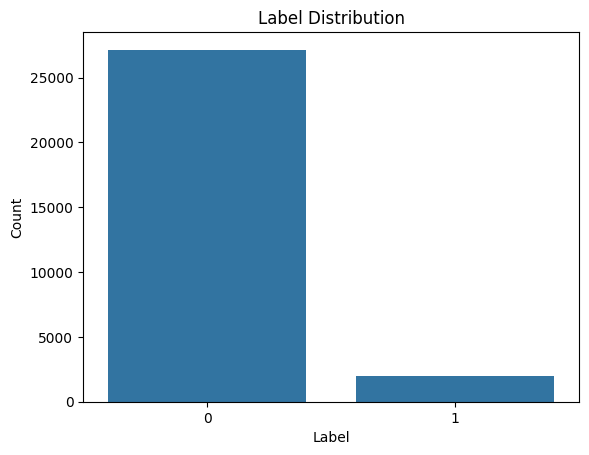

In [201]:
# show if there is any imbalance in the dataset - plotting using bar chart using seaborn
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

### Data splitting

It is a good practice to split the data before EDA helps maintain the integrity of the machine learning process, prevents data leakage, simulates real-world scenarios more accurately, and ensures reliable model performance evaluation on unseen data.

In [202]:
x = df.drop(columns=['label'])
y = df['label']

In [203]:
# Making stratified samples to ensure that the distribution of labels is similar in the dataset
x_train, x_valid_test, y_train, y_valid_test = train_test_split(x, y, test_size=0.3 ,stratify = y, random_state=99)
x_valid, x_test, y_valid, y_test = train_test_split(x_valid_test, y_valid_test, test_size=0.5, stratify = y_valid_test, random_state=99)

In [204]:
print(x_train.shape, x_valid.shape, x_test.shape)

(20391, 1) (4369, 1) (4370, 1)


### EDA & Preprocessing on training data

- show a representative sample of data texts to find out required preprocessing steps

In [205]:
x_train.values[0:10]

array([['ironic: when you dance like a moron, you feel like a genius!   #dance #geniusâ\x80¦ '],
       ['happy bihday too meeeeeee!! #june #junebaby   bday bdaytome #beautiful #cakeâ\x80¦'],
       ["can't believe this is my life"],
       ['@user dear @user @user @user @user would you please ask these shameless @user @user giveâ\x80¦'],
       ['va, boston, jersey then texass .. this summer is looking great ð\x9f\x99\x8cð\x9f\x8f¼  '],
       ['why does the government allow  behaviour?'],
       ['your actions are what make you happy #cow   #smile #quote #inspirational'],
       ['family trip to wegmans for some organic goods!  #wegmans #eat #organic #family #healthyliving'],
       ['you might be a libtard if... #libtard  #sjw #liberal #politics'],
       ['the pain of the shock then comes then the flood of sorrow, the ache of how can this happen again and again #writing #thoughts #poem  ']],
      dtype=object)

- Cleaning and Preprocessing are:
    - 1 applying lowercase 
    - 2 remove stop words 
    - 3 applying (Removing newlines and tabs - Removing URLs - Removing punctuations - Removing contractions (like i'm) - Characters normalization
                  Removing usernames & tags - Removing emojis - Removing numbers - Removing extra whitespaces ) 
    - 4 Tokenization
    - 5 Lemmatization


In [206]:
def text_preprocessing(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    # Normalize characters
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')
    
    # Lowercase
    text = text.lower()

    # Expand contractions
    contractions = {
        "can't": "can not", "won't": "will not", "n't": " not", "'re": " are",
        "'s": " is", "'d": " would", "'ll": " will", "'t": " not", "'ve": " have", "'m": " am"
    }
    for pattern, repl in contractions.items():
        text = re.sub(pattern, repl, text)

    # Remove URLs, usernames, hashtags, emojis, punctuation, numbers
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@[^\s]+', '', text)
    text = re.sub(r'#', '', text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # Remove newlines/tabs, extra whitespaces
    text = text.replace('\n', ' ').replace('\t', ' ')
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]

    # Join back into string
    text = ' '.join(tokens)

    return text

In [207]:
# x_train['tweet'] = x_train['tweet'].apply(text_preprocessing)
# x_train

### Cleaning and Preprocessing

#### Extra: use custom scikit-learn Transformers

Using custom transformers in scikit-learn provides flexibility, reusability, and control over the data transformation process, allowing you to seamlessly integrate with scikit-learn's pipelines, enabling you to combine multiple preprocessing steps and modeling into a single workflow. This makes your code more modular, readable, and easier to maintain.

##### link: https://www.andrewvillazon.com/custom-scikit-learn-transformers/

#### Example usage:

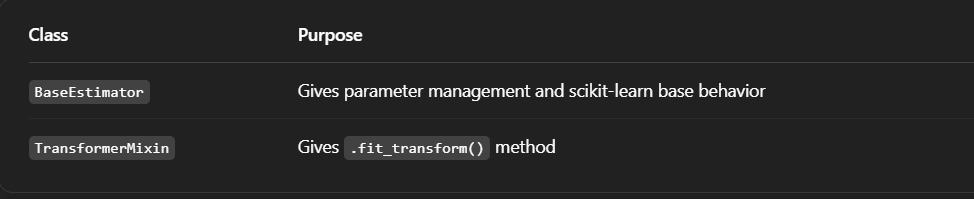

In [208]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # No fitting needed in preprocessing, just return self
        return self

    def transform(self, X):
        print(X.head())
        transformed_X = X.copy()

        # # Check if the text_column exists in the DataFrame
        # if self.text_column not in transformed_X.columns:
        #     raise KeyError(f"Column '{self.text_column}' not found in the input DataFrame")

        # Apply text preprocessing to the specified column
        transformed_X.tweet = transformed_X.tweet.apply(
             text_preprocessing
        )

        return transformed_X

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)


<B>Applying Feature Extraction (Vectorization)</B>

In [209]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

class VectorizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vectorizer_type='count', ngram_range=(1, 1), min_df=1, max_df=1.0):
        """
        vectorizer_type: 'count' or 'tfidf'
        ngram_range: tuple (min_n, max_n) for n-grams
        min_df: Minimum document frequency for feature inclusion
        max_df: Maximum document frequency for feature inclusion
        """
        if vectorizer_type == 'count':
            self.vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df, max_df=max_df)
        elif vectorizer_type == 'tfidf':
            self.vectorizer = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df, max_df=max_df)
        else:
            raise ValueError("Unsupported vectorizer type")

    def fit(self, X, y=None):
        self.vectorizer.fit(X)
        return self

    def transform(self, X):
        return self.vectorizer.transform(X)


**You  are doing Great so far!**

### Modelling

#### Extra: use scikit-learn pipline

##### link: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

Using pipelines in scikit-learn promotes better code organization, reproducibility, and efficiency in machine learning workflows.

#### Example usage:

In [210]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessing', CustomTransformer()),
    ('Vectorizing', VectorizerTransformer()),
    ('model', model),
])

grid = {
    'Vectorizing__vectorizer_type': ['tfidf'],
    'Vectorizing__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'Vectorizing__min_df': [1, 2, 3],
    'Vectorizing__max_df': [1.0, 0.8, 0.6],
}
# Now you can use the pipeline for training and prediction
pipeline.fit(x_train, y_train)
pipeline.predict(x_test)

                                                                                             tweet
2902             ironic: when you dance like a moron, you feel like a genius!   #dance #geniusâ¦ 
12173              happy bihday too meeeeeee!! #june #junebaby   bday bdaytome #beautiful #cakeâ¦
8386                                                                 can't believe this is my life
8984   @user dear @user @user @user @user would you please ask these shameless @user @user giveâ¦
23251                    va, boston, jersey then texass .. this summer is looking great ðð¼  


ValueError: Found input variables with inconsistent numbers of samples: [1, 20391]

In [ ]:
print(x_train.shape)
print(y_train.shape)

(20391, 1)
(20391,)


In [ ]:
y_train.shape

(20391,)

#### Evaluation

**Evaluation metric:**
macro f1 score

Macro F1 score is a useful metric in scenarios where you want to evaluate the overall performance of a multi-class classification model, **particularly when the classes are imbalanced**

![Calculation](https://assets-global.website-files.com/5d7b77b063a9066d83e1209c/639c3d934e82c1195cdf3c60_macro-f1.webp)

### Enhancement

- Using different vectorizers with different hyperparameters
- Trying different ML models and doing hyperparameter tuning

### Conclusion and final results


#### Done!